In [1]:
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from collections import defaultdict
from torch.utils.data import DataLoader, Subset

import src.data_cleaning_and_preprocessing._model_ready_dataset as model_ready_dataset
from archive.dataset.tiny_imagenet_dataset import TinyImageNetLoader
from src.pc_4_classify_bp import HierarchicalPCCNN

In [2]:
SEED = 42
BATCH_SIZE = 16

NUM_CLASSES = 10
IMAGES_PER_CLASS = 50

INFERENCE_STEPS = 100

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: mps


In [4]:
cleaned_tiny_imagenet = model_ready_dataset.ModelReadyDatasetLoader(
    TinyImageNetLoader(seed=SEED), image_size=64
).load()

train_dataset = cleaned_tiny_imagenet[0]
test_dataset = cleaned_tiny_imagenet[1]

In [5]:
selected_classes = list(range(NUM_CLASSES))

class_indices = defaultdict(list)

for i in range(len(train_dataset)):
    _, label = train_dataset[i]
    label = int(label)

    if label in selected_classes:
        class_indices[label].append(i)

generator = torch.Generator()
generator.manual_seed(SEED)

indices = []

for class_id in selected_classes:
    available_indices = class_indices[class_id]

    if len(available_indices) < IMAGES_PER_CLASS:
        raise ValueError(
            f"Class {class_id} has only {len(available_indices)} images, but {IMAGES_PER_CLASS} were requested.")

    perm = torch.randperm(len(available_indices), generator=generator)[:IMAGES_PER_CLASS]
    selected = [available_indices[i] for i in perm.tolist()]
    indices.extend(selected)

train_subset = Subset(train_dataset, indices)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator
)

print("Total Tiny ImageNet training images:", len(train_dataset))
print("Selected classes:", selected_classes)
print("Number of selected classes:", len(selected_classes))
print("Images per class:", IMAGES_PER_CLASS)
print("Training images:", len(train_subset))
print("Training batches:", len(train_loader))

Total Tiny ImageNet training images: 99953
Selected classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Number of selected classes: 10
Images per class: 50
Training images: 500
Training batches: 32


In [6]:
# ====================================================
# TEST DATASET - SAME CLASSES AS TRAINING
# ====================================================

test_dataset = cleaned_tiny_imagenet[1]

test_class_indices = defaultdict(list)

for i in range(len(test_dataset)):
    _, label = test_dataset[i]
    label = int(label)

    if label in selected_classes:
        test_class_indices[label].append(i)


# ====================================================
# SELECT TEST IMAGES FROM SAME CLASSES
# ====================================================

test_generator = torch.Generator()
test_generator.manual_seed(SEED)

test_indices = []

for class_id in selected_classes:
    available_indices = test_class_indices[class_id]

    if len(available_indices) < IMAGES_PER_CLASS:
        raise ValueError(
            f"Test class {class_id} has only {len(available_indices)} images, "
            f"but {IMAGES_PER_CLASS} were requested."
        )

    perm = torch.randperm(len(available_indices), generator=test_generator)[:IMAGES_PER_CLASS]
    selected = [available_indices[i] for i in perm.tolist()]
    test_indices.extend(selected)


# ====================================================
# TEST SUBSET AND LOADER
# ====================================================

test_subset = Subset(test_dataset, test_indices)

test_loader = DataLoader(
    test_subset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ====================================================
# SUMMARY
# ====================================================

print("Total Tiny ImageNet test images:", len(test_dataset))
print("Selected test classes:", selected_classes)
print("Number of selected classes:", len(selected_classes))
print("Images per class:", IMAGES_PER_CLASS)
print("Test images:", len(test_subset))
print("Test batches:", len(test_loader))

Total Tiny ImageNet test images: 9993
Selected test classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Number of selected classes: 10
Images per class: 50
Test images: 500
Test batches: 32


In [7]:
model = HierarchicalPCCNN(
    inference_steps=INFERENCE_STEPS,
    num_classes=NUM_CLASSES,
).to(device)

print(model)

HierarchicalPCCNN(
  (level1): ModuleDict(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (deconv): ConvTranspose2d(32, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1), bias=False)
  )
  (level2): ModuleDict(
    (conv): Conv2d(32, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (deconv): ConvTranspose2d(128, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1), bias=False)
  )
  (classifier_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Linear(in_features=2048, out_features=10, bias=True)
)


In [8]:
pc_epochs = 10

for epoch in range(pc_epochs):
    total_error_0 = 0.0
    total_error_1 = 0.0
    total_images = 0

    for images, labels in tqdm(train_loader, desc=f"PC-CNN Epoch {epoch + 1}/{pc_epochs}"):
        for image in images:
            result = model(image)

            total_error_0 += result["error_0"]
            total_error_1 += result["error_1"]
            total_images += 1

    mean_error_0 = total_error_0 / total_images
    mean_error_1 = total_error_1 / total_images

    print(
        f"Epoch {epoch + 1}/{pc_epochs} | "
        f"Image Error: {mean_error_0:.6f} | "
        f"r1 Error: {mean_error_1:.6f}"
    )

PC-CNN Epoch 1/10:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/10 | Image Error: 0.116043 | r1 Error: 0.055926


PC-CNN Epoch 2/10:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2/10 | Image Error: 0.088784 | r1 Error: 0.042315


PC-CNN Epoch 3/10:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 8/10 | Image Error: 0.058462 | r1 Error: 0.048583


PC-CNN Epoch 9/10:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 9/10 | Image Error: 0.056680 | r1 Error: 0.048186


PC-CNN Epoch 10/10:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 10/10 | Image Error: 0.055283 | r1 Error: 0.047800


In [9]:
from torch import nn

# ====================================================
# CLASSIFICATION SETUP
# ====================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

classification_epochs = 10

In [10]:
# ====================================================
# TRAIN CLASSIFIER
# ====================================================

def train_classifier(model: HierarchicalPCCNN, train_loader, criterion, optimizer, device):
    model.classifier.train()

    total_loss = 0.0
    total_correct = 0
    total_images = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model.classify(images)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        predictions = logits.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)
        total_correct += (predictions == labels).sum().item()
        total_images += labels.size(0)

    mean_loss = total_loss / total_images
    accuracy = 100.0 * total_correct / total_images

    return mean_loss, accuracy

In [11]:
# ====================================================
# TEST CLASSIFIER
# ====================================================

@torch.no_grad()
def test_classifier(model, test_loader, criterion, device):
    model.classifier.eval()

    total_loss = 0.0
    total_correct = 0
    total_images = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model.classify(images)

        loss = criterion(logits, labels)

        predictions = logits.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)
        total_correct += (predictions == labels).sum().item()
        total_images += labels.size(0)

    mean_loss = total_loss / total_images
    accuracy = 100.0 * total_correct / total_images

    return mean_loss, accuracy

In [12]:
best_val_accuracy = 0.0
best_classifier_state = None

classification_history = []

for epoch in tqdm(range(classification_epochs), desc="Classification Training"):

    train_loss, train_accuracy = train_classifier(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = test_classifier(
        model,
        test_loader,
        criterion,
        device
    )

    classification_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_classifier_state = {
            key: value.detach().cpu().clone()
            for key, value in model.classifier.state_dict().items()
        }

    print(
        f"Epoch {epoch + 1}/{classification_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )

Classification Training:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 2.3056 | Train Accuracy: 12.20% | Val Loss: 2.2549 | Val Accuracy: 14.20%
Epoch 2/10 | Train Loss: 2.2176 | Train Accuracy: 19.40% | Val Loss: 2.2034 | Val Accuracy: 19.80%
Epoch 3/10 | Train Loss: 2.1570 | Train Accuracy: 23.60% | Val Loss: 2.1724 | Val Accuracy: 19.40%
Epoch 4/10 | Train Loss: 2.1179 | Train Accuracy: 25.00% | Val Loss: 2.1533 | Val Accuracy: 20.20%
Epoch 5/10 | Train Loss: 2.0870 | Train Accuracy: 24.40% | Val Loss: 2.1249 | Val Accuracy: 23.20%
Epoch 6/10 | Train Loss: 2.0412 | Train Accuracy: 29.60% | Val Loss: 2.1122 | Val Accuracy: 24.00%
Epoch 7/10 | Train Loss: 2.0000 | Train Accuracy: 33.40% | Val Loss: 2.0984 | Val Accuracy: 20.60%
Epoch 8/10 | Train Loss: 1.9970 | Train Accuracy: 29.80% | Val Loss: 2.0980 | Val Accuracy: 22.40%
Epoch 9/10 | Train Loss: 1.9769 | Train Accuracy: 34.20% | Val Loss: 2.1006 | Val Accuracy: 24.80%
Epoch 10/10 | Train Loss: 1.9637 | Train Accuracy: 32.80% | Val Loss: 2.0778 | Val Accuracy: 22.40%


In [13]:
model.classifier.load_state_dict(best_classifier_state)

print("Best Validation Accuracy:", best_val_accuracy)

Best Validation Accuracy: 24.8


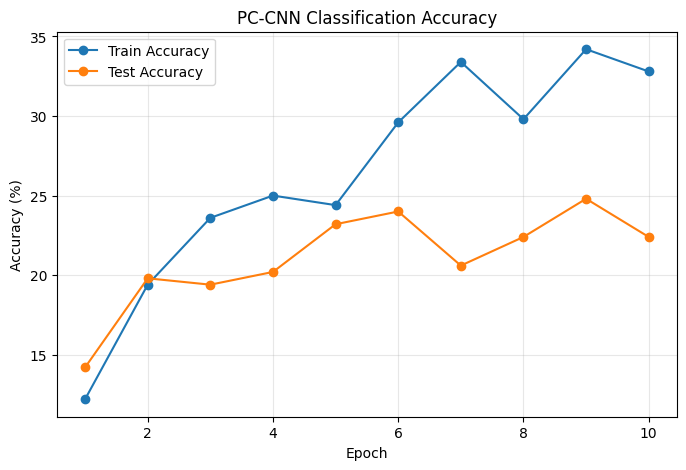

In [14]:
epochs_plot = [item["epoch"] for item in classification_history]
train_accuracy_plot = [item["train_accuracy"] for item in classification_history]
test_accuracy_plot = [item["val_accuracy"] for item in classification_history]

plt.figure(figsize=(8, 5))

plt.plot(epochs_plot, train_accuracy_plot, marker="o", label="Train Accuracy")
plt.plot(epochs_plot, test_accuracy_plot, marker="o", label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("PC-CNN Classification Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

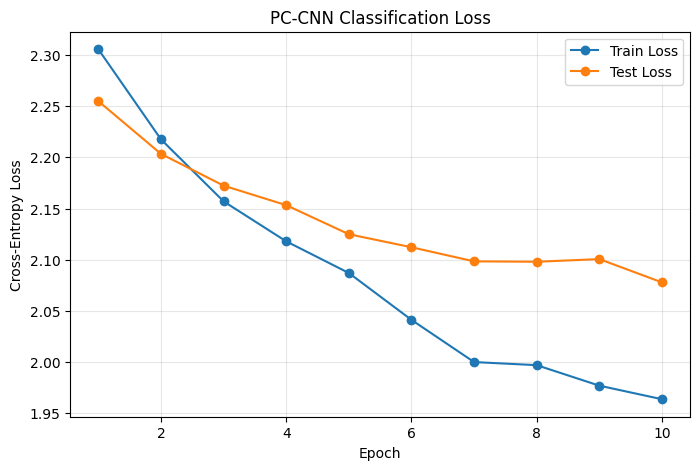

In [15]:
train_loss_plot = [item["train_loss"] for item in classification_history]
test_loss_plot = [item["val_loss"] for item in classification_history]

plt.figure(figsize=(8, 5))

plt.plot(epochs_plot, train_loss_plot, marker="o", label="Train Loss")
plt.plot(epochs_plot, test_loss_plot, marker="o", label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("PC-CNN Classification Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

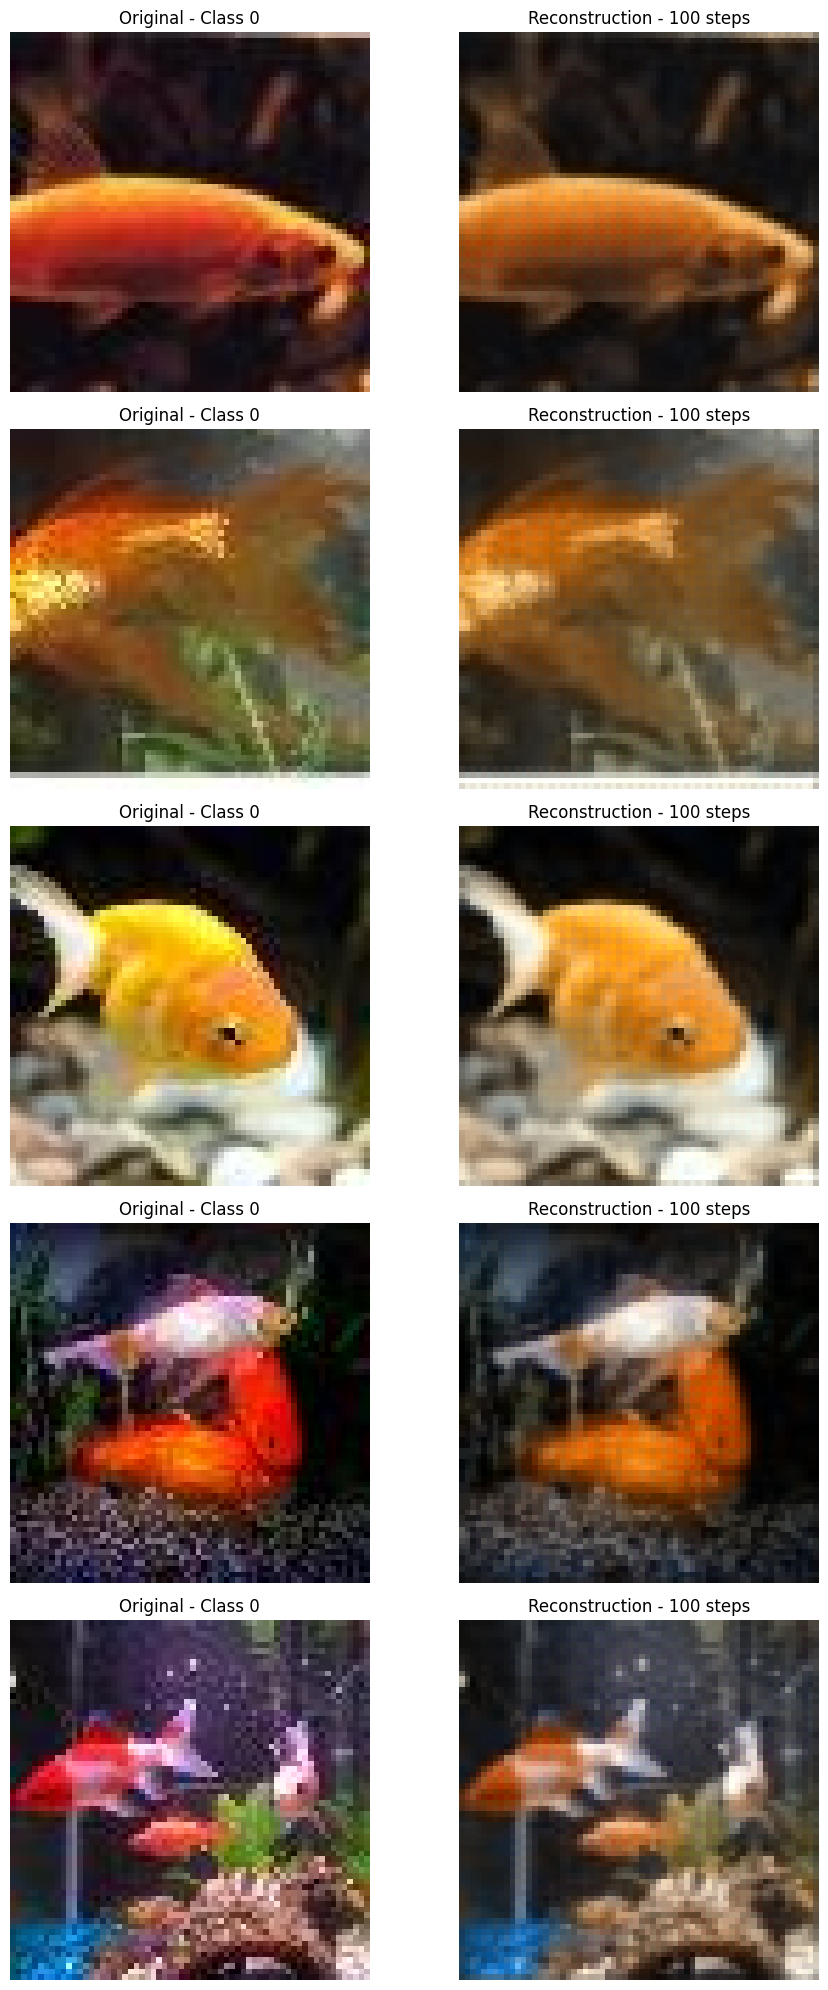

In [16]:
def to_display_image(image):
    image = image.detach().cpu().clamp(0, 1)
    return image.permute(1, 2, 0).numpy()


num_images = 5

fig, axes = plt.subplots(num_images, 2, figsize=(10, num_images * 4))

for i in range(num_images):
    image, label = train_subset[i]

    reconstruction, predicted_r1, reconstruction_r2, r2, steps, converged = model.reconstruct(image)

    axes[i, 0].imshow(to_display_image(image))
    axes[i, 0].set_title(f"Original - Class {label}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(to_display_image(reconstruction))
    axes[i, 1].set_title(f"Reconstruction - {steps} steps")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [17]:
@torch.no_grad()
def evaluate_per_class(model: HierarchicalPCCNN, data_loader, device, num_classes):
    class_correct = torch.zeros(num_classes, dtype=torch.long)
    class_total = torch.zeros(num_classes, dtype=torch.long)

    model.eval()

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device=device, dtype=torch.long)

        # Get classification logits
        logits = model.classify(images)

        # Convert logits to predicted class IDs
        predictions = logits.argmax(dim=1)

        for class_id in range(num_classes):
            mask = labels == class_id

            class_correct[class_id] += (
                predictions[mask] == labels[mask]
            ).sum().cpu()

            class_total[class_id] += mask.sum().cpu()

    print("\nPER-CLASS ACCURACY")
    print("=" * 60)

    for class_id in range(num_classes):

        total = class_total[class_id].item()
        correct = class_correct[class_id].item()

        if total > 0:
            accuracy = 100.0 * correct / total
        else:
            accuracy = 0.0

        print(
            f"Class {class_id} | "
            f"Correct: {correct}/{total} | "
            f"Accuracy: {accuracy:.2f}%"
        )

In [18]:
evaluate_per_class(
    model,
    test_loader,
    device,
    NUM_CLASSES
)




PER-CLASS ACCURACY
Class 0 | Correct: 35/50 | Accuracy: 70.00%
Class 1 | Correct: 0/50 | Accuracy: 0.00%
Class 2 | Correct: 0/50 | Accuracy: 0.00%
Class 3 | Correct: 11/50 | Accuracy: 22.00%
Class 4 | Correct: 27/50 | Accuracy: 54.00%
Class 5 | Correct: 5/50 | Accuracy: 10.00%
Class 6 | Correct: 11/50 | Accuracy: 22.00%
Class 7 | Correct: 0/50 | Accuracy: 0.00%
Class 8 | Correct: 28/50 | Accuracy: 56.00%
Class 9 | Correct: 8/50 | Accuracy: 16.00%
